In [12]:
from dotenv import load_dotenv
import os

import glob
from pathlib import Path

import cv2
import numpy as np


from matplotlib import pyplot as plt

load_dotenv()

True

In [8]:

from deblur.detection import calc_blur_laplacian, calc_blur_fft


def measure(image_dir):
    glob_mask = image_dir / "*"
    files = glob.glob(str(glob_mask))
    files = [Path(file) for file in files]
    files.sort(key=lambda x: int(x.stem))

    results = []
    for file in files:
        loaded_image = cv2.imread(str(file))
        laplacian = calc_blur_laplacian(loaded_image)
        fft = calc_blur_fft(loaded_image)
        results.append((file, laplacian, fft))

    return np.array(results)


def check_measurements(name: str, measurement: np.ndarray):
    print(name)

    laplacian = measurement[:, 1].std()
    ftt = measurement[:, 2].std()
    print(f"std - laplacian: {laplacian}, FFT: {ftt}")

    laplacian = measurement[:, 1].mean()
    ftt = measurement[:, 2].mean()
    print(f"mean - laplacian: {laplacian}, FFT: {ftt}")

    laplacian = np.median(measurement[:, 1])
    ftt = np.median(measurement[:, 2])
    print(f"median - laplacian: {laplacian}, FFT: {ftt}")

    plt.hist(measurement[:, 1])
    plt.title(f"{name} - Laplacian histogram")
    plt.show()

    plt.hist(measurement[:, 2])
    plt.title(f"{name} - FFT histogram")
    plt.show()



blurred
std - laplacian: 350.15859274747226, FFT: 7.803428332787851
mean - laplacian: 948.353973901323, FFT: 41.33520485737521
median - laplacian: 955.6149104557234, FFT: 42.05949219308235


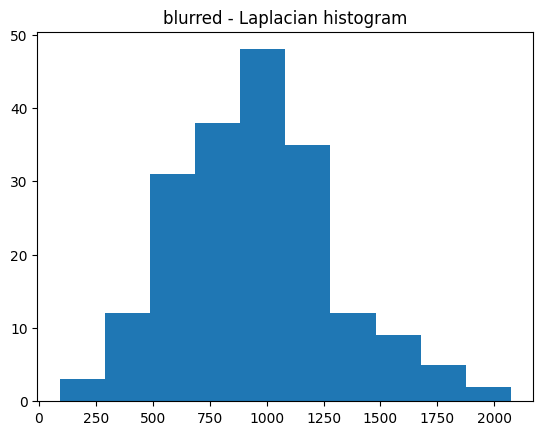

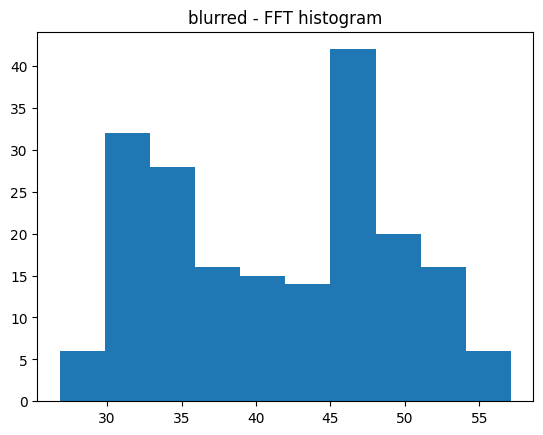

In [9]:
blurred = measure(Path(os.getenv("VERTICAL_BLURRED")))
check_measurements("blurred", blurred)

sharp
std - laplacian: 274.6213331439136, FFT: 4.175539564105839
mean - laplacian: 809.9149974034127, FFT: 58.56353397695483
median - laplacian: 706.5884290827297, FFT: 57.86063331805858


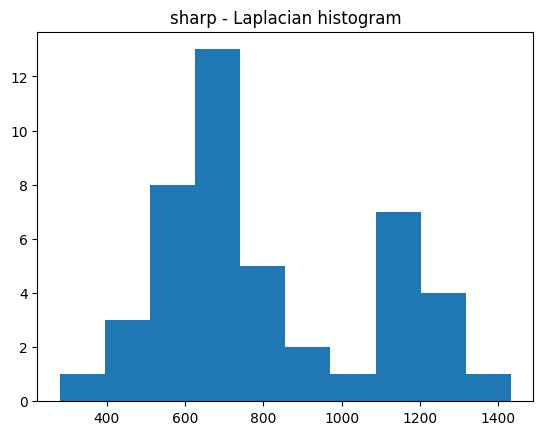

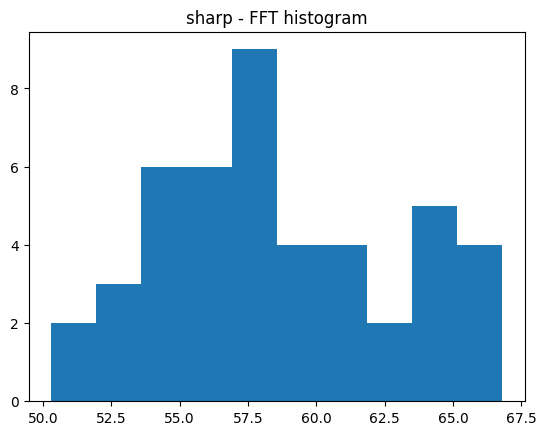

In [11]:
sharp = measure(Path(os.getenv("VERTICAL_SHARP")))
check_measurements("sharp", sharp)

### Laplacian: x < 750 -> ostry
### FFT: x > 55 -> ostry

